In [46]:
import deepinv as dinv
import torch
import pywt

PSNR = dinv.metric.PSNR()

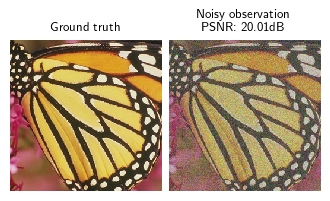

In [47]:
x_true = dinv.utils.load_example("butterfly.png", device='cpu')

gaussian_noise = dinv.physics.GaussianNoise(sigma=0.1)
physics = dinv.physics.Denoising(gaussian_noise)

y = physics(x_true)
psnr_y = PSNR(x_true, y).item()

dinv.utils.plot([x_true, y], titles=['Ground truth', f'Noisy observation\n PSNR: {psnr_y:.2f}dB'])

### Denoising with DeepInv's WaveletDenoiser

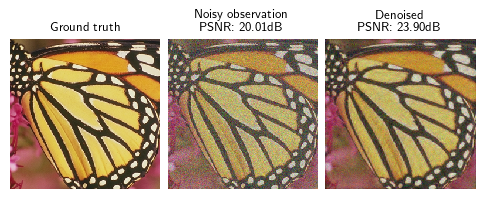

In [48]:
wavelet_denoiser = dinv.models.WaveletDenoiser(level=3, wv='db8')

y_denoised = wavelet_denoiser(y, ths=0.1)
psnr_y_denoised = PSNR(x_true, y_denoised).item()

dinv.utils.plot([x_true, y, y_denoised], titles=['Ground truth', f'Noisy observation\n PSNR: {psnr_y:.2f}dB', f'Denoised\n PSNR: {psnr_y_denoised:.2f}dB'])

### Custom wavelet denoising

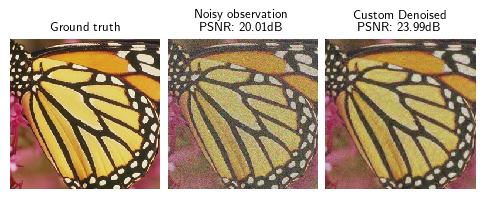

In [49]:
y_wavelet = pywt.wavedec2(y.cpu().numpy(), 'db8', level=3)
y_wavelet_thresholded = [y_wavelet[0]]

soft_thresholding = lambda x, thresh: dinv.optim.L1Prior().prox(x=x, gamma=thresh)

for j in range(1, len(y_wavelet)):
    y_wavelet_thresholded.append(
        tuple(
            soft_thresholding(
                torch.from_numpy(y_wavelet[j][c]),
                thresh=0.1
            ).numpy() for c in range(3)
        )
    )

y_denoised_custom = torch.from_numpy(pywt.waverec2(y_wavelet_thresholded, 'db8'))

dinv.utils.plot([x_true, y, y_denoised_custom], titles=['Ground truth', f'Noisy observation\n PSNR: {psnr_y:.2f}dB', f'Custom Denoised\n PSNR: {PSNR(x_true, y_denoised_custom).item():.2f}dB'])

### Comparing reconstructions

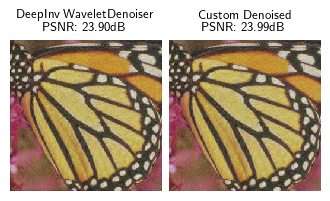

Norm of the difference: 5.5449700355529785


In [50]:
dinv.utils.plot([y_denoised, y_denoised_custom], titles=[f'DeepInv WaveletDenoiser\n PSNR: {psnr_y_denoised:.2f}dB', f'Custom Denoised\n PSNR: {PSNR(x_true, y_denoised_custom).item():.2f}dB'])

print(f'Norm of the difference: {torch.norm(y_denoised - y_denoised_custom).item()}')